# **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,roc_auc_score,roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


# **LOAD** **DATASET**

In [2]:
from google.colab import files
upload = files.upload()
df=pd.read_csv('heart.csv')
print("dataset loaded!")
print(f"Shape:{df.shape}")
df.head()

Saving heart.csv to heart.csv
dataset loaded!
Shape:(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# **EXPLORATORY DATA ANALYSIS(EDA)**

In [3]:
print("----DATASET INFO-----")
df.info()

print("\n-----MISSING VALUES------")
print(df.isnull().sum())

print("\n-----STATISTICS-------")
df.describe()

----DATASET INFO-----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

-----MISSING VALUES------
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**TARGET DISTRIBUTION PLOT**

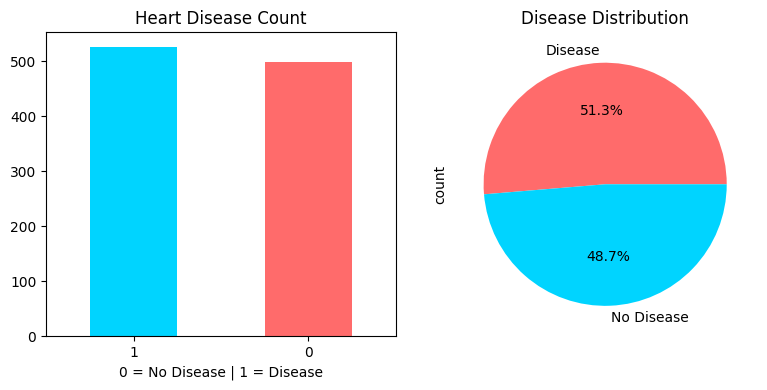

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
df['target'].value_counts().plot(kind='bar', color=['#00d4ff', '#ff6b6b'])
plt.title('Heart Disease Count')
plt.xlabel('0 = No Disease | 1 = Disease')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['target'].value_counts().plot(kind='pie',
    labels=['Disease', 'No Disease'],
        colors=['#ff6b6b', '#00d4ff'],
            autopct='%1.1f%%')
plt.title('Disease Distribution')

plt.tight_layout()
plt.show()

**AGE & GENDER ANALYSIS**

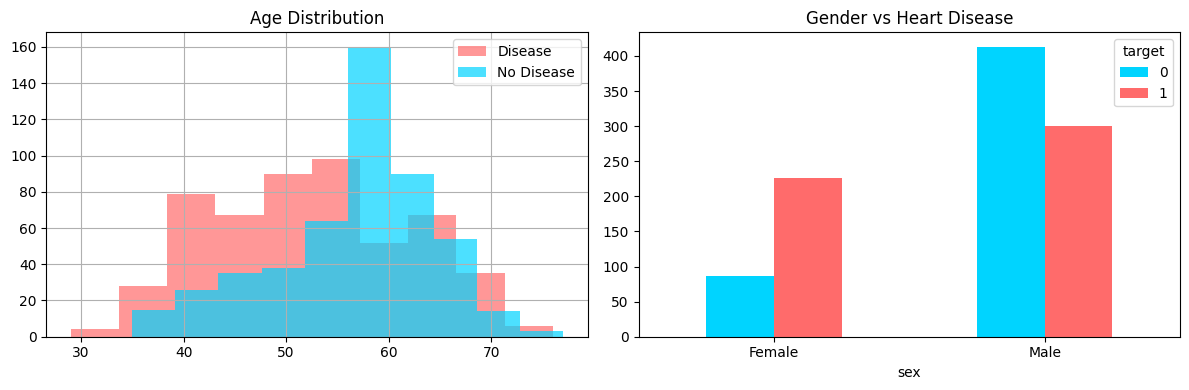

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution by disease

df[df['target']==1]['age'].hist(ax=axes[0], color='#ff6b6b',
                                alpha=0.7, label='Disease')
df[df['target']==0]['age'].hist(ax=axes[0], color='#00d4ff',
                                alpha=0.7, label='No Disease')
axes[0].set_title('Age Distribution')
axes[0].legend()

# Gender vs disease

pd.crosstab(df['sex'], df['target']).plot(
    kind='bar', ax=axes[1],
    color=['#00d4ff', '#ff6b6b'])
axes[1].set_title('Gender vs Heart Disease')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)

plt.tight_layout()
plt.show()

**CORRELATION HEATMAP**

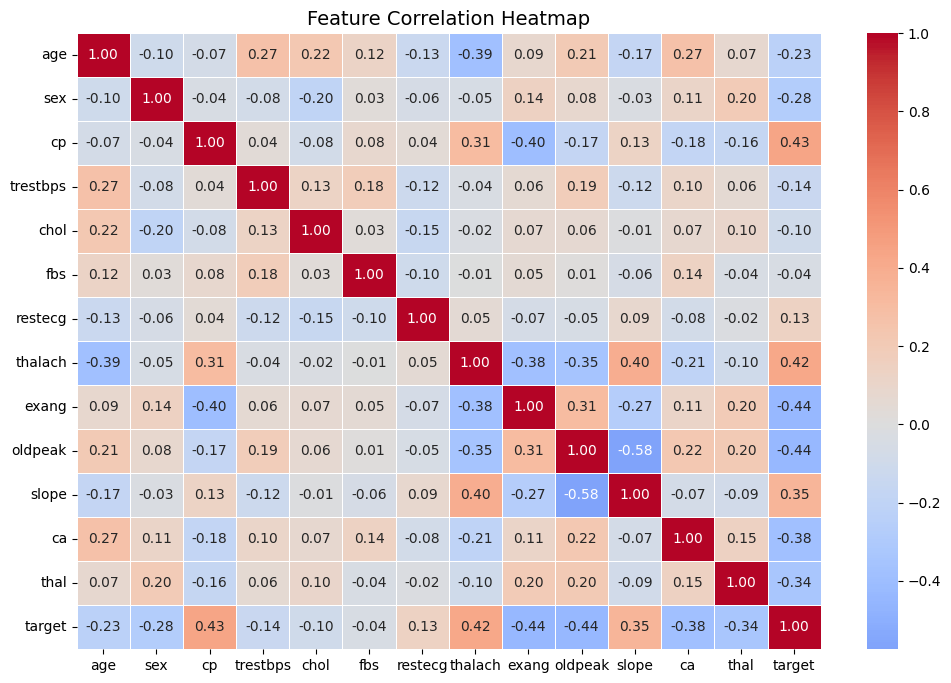


Top correlations with Heart Disease:
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

# Top features correlated with target
print("\nTop correlations with Heart Disease:")
print(df.corr()['target'].sort_values(ascending=False))

**SEPARATE FEATURES & TARGET**

In [7]:
# X = input features (all columns except target)
# y = what we want to predict
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")   # (1025, 13)
print(f"Target shape: {y.shape}")     # (1025,)
print(f"\nFeature columns:\n{list(X.columns)}")

Features shape: (1025, 13)
Target shape: (1025,)

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


**TRAIN TEST SPLIT**

In [8]:
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
        test_size=0.2,
            random_state=42,
                stratify=y
                )

print(f"Training samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"\nTrain disease ratio: {y_train.mean():.2f}")
print(f"Test disease ratio:  {y_test.mean():.2f}")

Training samples:   820
Testing samples:    205

Train disease ratio: 0.51
Test disease ratio:  0.51


**FEATURE SCALING**

In [9]:
# StandardScaler: converts all features to same scale
# age=50 and chol=250 — different scales, confuses model
scaler = StandardScaler()

# Fit on train, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")
print(f"Sample scaled values: {X_train_scaled[0][:5].round(2)}")

Scaling done!
Sample scaled values: [ 0.81 -1.51 -0.91  0.31  0.9 ]


**BUILD ML MODELS**

**LOGISTIC REGRESSION**

In [10]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f" Logistic Regression Accuracy: {lr_acc*100:.2f}%")

 Logistic Regression Accuracy: 80.98%


**RANDOM FOREST**

In [11]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
        max_depth=5,
            random_state=42
            )
rf_model.fit(X_train_scaled, y_train)

# Predictions
rf_pred = rf_model.predict(X_test_scaled)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f"✅ Random Forest Accuracy: {rf_acc*100:.2f}%")

✅ Random Forest Accuracy: 92.68%


**COMPARE MODELS**

In [12]:
print("=" * 40)
print("       MODEL COMPARISON")
print("=" * 40)
print(f"Logistic Regression : {lr_acc*100:.2f}%")
print(f"Random Forest       : {rf_acc*100:.2f}%")
print("=" * 40)

# Select best model
best_model = rf_model if rf_acc > lr_acc else lr_model
best_pred  = rf_pred  if rf_acc > lr_acc else lr_pred
best_name  = "Random Forest" if rf_acc > lr_acc else "Logistic Regression"
print(f"\n Best Model: {best_name}")

       MODEL COMPARISON
Logistic Regression : 80.98%
Random Forest       : 92.68%

 Best Model: Random Forest


**CONFUSION MATRIX**

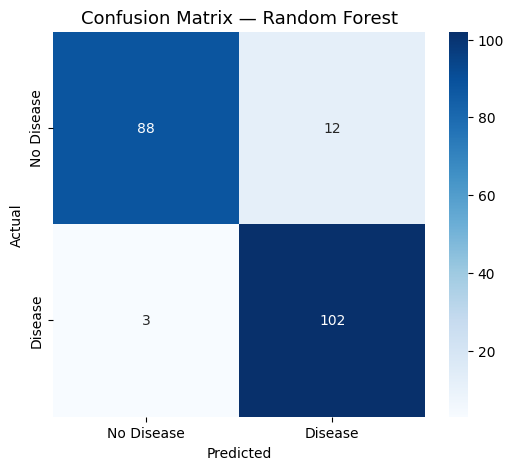


True Negatives  (Correctly said No Disease): 88
False Positives (Said Disease, but No):       12
False Negatives (Missed Disease!):            3
True Positives  (Correctly found Disease):    102


In [13]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix — {best_name}', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Explain the matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Correctly said No Disease): {tn}")
print(f"False Positives (Said Disease, but No):       {fp}")
print(f"False Negatives (Missed Disease!):            {fn}")
print(f"True Positives  (Correctly found Disease):    {tp}")

**CLASSIFICATION  REPORT**

In [14]:
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, best_pred,
    target_names=['No Disease', 'Disease']))

# ROC-AUC Score
roc = roc_auc_score(y_test, best_pred)
print(f"ROC-AUC Score: {roc:.4f}")


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  No Disease       0.97      0.88      0.92       100
     Disease       0.89      0.97      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205

ROC-AUC Score: 0.9257


**FEATURE IMPORTANCE**

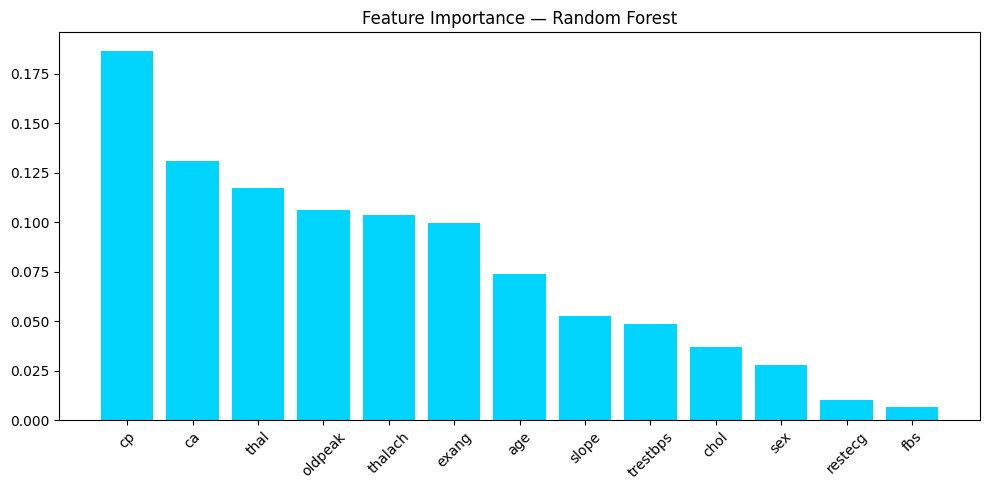


Top 5 Important Features:
feature  importance
     cp    0.186490
     ca    0.130705
   thal    0.117188
oldpeak    0.106199
thalach    0.103327


In [15]:
# Which features matter most?
feature_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(feature_imp['feature'],
        feature_imp['importance'],
        color='#00d4ff')
plt.title('Feature Importance — Random Forest')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop 5 Important Features:")
print(feature_imp.head(5).to_string(index=False))

**PREDICT ON NEW PATIENT DATA**

In [16]:
# Enter a new patient's details here
# [age, sex, cp, trestbps, chol, fbs, restecg,
#  thalach, exang, oldpeak, slope, ca, thal]

new_patient = np.array([[
    52,   # age
    1,    # sex (1=Male)
    0,    # cp (chest pain type)
    125,  # trestbps (blood pressure)
    212,  # chol (cholesterol)
    0,    # fbs
    1,    # restecg
    168,  # thalach (max heart rate)
    0,    # exang
    1.0, # oldpeak
    2,    # slope
    2,    # ca
    3     # thal
]])

# Scale the input
patient_scaled = scaler.transform(new_patient)

# Predict
prediction = best_model.predict(patient_scaled)
probability = best_model.predict_proba(patient_scaled)

print("=" * 45)
print("         HEART DISEASE PREDICTION")
print("=" * 45)
if prediction[0] == 1:
    print("RESULT: Heart Disease DETECTED")
else:
    print("RESULT: No Heart Disease")
print(f"\nProbability of Disease:    {probability[0][1]*100:.1f}%")
print(f"Probability of No Disease: {probability[0][0]*100:.1f}%")
print("=" * 45)

         HEART DISEASE PREDICTION
RESULT: No Heart Disease

Probability of Disease:    19.8%
Probability of No Disease: 80.2%


**SAVAE MODEL**

In [17]:
import pickle

# Save model and scaler
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

    with open('scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

        print("✅ Model saved as 'heart_disease_model.pkl'")
        print("✅ Scaler saved as 'scaler.pkl'")

        # Download files to your PC
        from google.colab import files
        files.download('heart_disease_model.pkl')

✅ Model saved as 'heart_disease_model.pkl'
✅ Scaler saved as 'scaler.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>